# The battery's calibration

Before it judges any theory, the battery is run on cases whose truth is known. Eleven kinds of
case, each drawn 200 times on the real snapshot, 2005 to 2025:

| Case | What it is | What the battery must do |
|---|---|---|
| timing | a rule driven by a random signal, on real prices, reset every five sessions: it earns what being invested pays, and nothing more | pass at most 5% |
| slow timing | the same null from a slower signal, in equal parts, reset every 21 sessions: far cheaper to trade, and favouring no asset on average | pass at most 5% |
| selection | the best in-sample of ten timing rules, judged with the nine others in the registry | pass at most 5% |
| slow selection | the same, among ten slow rules | pass at most 5% |
| planted 0.5 | real prices, plus a return that the rule's signal predicts, for an expected in-sample appraisal ratio of 0.5 | reported |
| planted 0.8 | the same, for an appraisal ratio of 0.8 | pass at least half |
| late slow timing | the slow timing null on SPY, XLRE, XLC and bitcoin, in-sample from 2012: three of its four assets start trading inside the period | pass at most 5% |
| rotation | a rule without skill that is always fully invested: every two spans of sessions a random share on SPY and QQQ, the rest on XLRE and XLC once they trade, in-sample from 2012 | pass at most 5% |
| binary rotation | the same, all on one side or the other at a coin's toss | pass at most 5% |
| top sector | a rule without skill that holds the one sector fund of highest slow noise among the eleven, reset every 21 sessions, in-sample from 2012: XLRE and XLC start late | pass at most 5% |
| near benchmark | a rule without skill close to its benchmark, never the benchmark itself: every sector fund that trades but the one of lowest fast noise, reset every 21 sessions, in-sample from 2012 | pass at most 5% |

The appraisal ratio is the Sharpe ratio of the strategy's excess returns hedged of its benchmark:
its own bets, beyond what being invested pays, which gates 2, 4, 5 and 7 judge. The first six cases
run one rule, with two variants, spans of 10 and 20 sessions, and four parameter neighbours; only
the signal differs. The five nulls from 2012 run their own rules, with the same variants and
neighbours: the rotations take the span as their pace, the top rules as their signal's average. The
four late nulls are where gate 3's placebos were weakest, before a placebo that draws its weights
from a day after an asset's start, onto a day before it, filled the share it cannot hold yet with
the strategy's own weights of that day. The near-benchmark null is close to its benchmark, never the
benchmark itself: its placebos differ from it by little, and details of the path decide its rank.
Until XLRE starts, the two rotations hold SPY and QQQ in equal parts, the benchmark itself: their
first block's alpha is zero, gate 5 cannot pass them, and their rows measure the gates before it.
`python -m lab.calibration` draws the cases, writes `results.csv` and runs this notebook again.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("results.csv")
NULLS = ["timing", "slow timing", "selection", "slow selection", "late slow timing", "rotation", "binary rotation",
         "top sector", "near benchmark"]
PLANTED = ["planted 0.5", "planted 0.8"]
ORDER = NULLS + PLANTED
REQUIRED = {**{case: "at most 5%" for case in NULLS}, "planted 0.5": "reported", "planted 0.8": "at least 50%"}


def wilson(passed, n, z=1.96):
    p = passed / n
    centre = (p + z * z / (2 * n)) / (1 + z * z / n)
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / (1 + z * z / n)
    return centre - half, centre + half


rows = []
for case in ORDER:
    part = results[results["case"] == case]
    low, high = wilson(part["passed"].sum(), len(part))
    rows.append({"case": case, "draws": len(part), "passed": int(part["passed"].sum()),
                 "pass rate": f"{part['passed'].mean():.1%}", "95% interval": f"{low:.1%} to {high:.1%}",
                 "required": REQUIRED[case]})
pd.DataFrame(rows).set_index("case")

,draws,passed,pass rate,95% interval,required
case,,,,,
timing,200,0,0.0%,0.0% to 1.9%,at most 5%
slow timing,200,3,1.5%,0.5% to 4.3%,at most 5%
selection,200,0,0.0%,0.0% to 1.9%,at most 5%
slow selection,200,1,0.5%,0.1% to 2.8%,at most 5%
late slow timing,200,0,0.0%,0.0% to 1.9%,at most 5%
rotation,200,0,0.0%,0.0% to 1.9%,at most 5%
binary rotation,200,0,0.0%,0.0% to 1.9%,at most 5%
top sector,200,0,0.0%,0.0% to 1.9%,at most 5%
near benchmark,200,0,0.0%,0.0% to 1.9%,at most 5%


The intervals treat the draws as independent. They are not quite: every draw of a case runs on
the same price history, and only the signal differs, so the true uncertainty is somewhat wider.

## The verdict

In [2]:
rate = results.groupby("case")["passed"].mean()
checks = {**{f"{case} null at most 5%": rate[case] <= 0.05 for case in NULLS},
          "planted 0.8 at least half": rate["planted 0.8"] >= 0.5}
for label, ok in checks.items():
    print(f"{'passes' if ok else 'FAILS '}  {label}")
print()
print("The battery is calibrated." if all(checks.values()) else "The battery is not calibrated.")

passes  timing null at most 5%
passes  slow timing null at most 5%
passes  selection null at most 5%
passes  slow selection null at most 5%
passes  late slow timing null at most 5%
passes  rotation null at most 5%
passes  binary rotation null at most 5%
passes  top sector null at most 5%
passes  near benchmark null at most 5%
passes  planted 0.8 at least half

The battery is calibrated.


## What the nulls pay

A null that pays heavy costs fails gate 2 on its costs, whatever its timing: it would test the
costs, not the gates built against luck and selection. The fast nulls reset every five sessions and
pay about 1% a year; the slow ones, and the four nulls where assets start late, pay a quarter to a
third of that, and the near-benchmark null, close to its benchmark, a tenth. The slow timing null
keeps an alpha close to zero before costs, as a rule without skill should; its late twin, the top
sector rule and the near-benchmark null show a positive alpha on 43% to 50% of their draws, the two
rotations on about a third. The slow selection null, the best of ten such rules, shows a positive
alpha on nearly every draw, by selection alone, and passes gate 2 almost always: it is the test of
gates 3 and 4.

In [3]:
nulls = results[results["case"].isin(NULLS)]
paid = nulls.groupby("case").agg(**{"costs a year": ("costs a year", "mean"), "alpha, net of costs": ("alpha", "mean"),
                                    "alpha before costs": ("alpha", lambda a: (a + nulls.loc[a.index, "costs a year"]).mean()),
                                    "share with alpha above zero": ("alpha", lambda a: (a > 0).mean())}).reindex(NULLS)
paid.map(lambda v: f"{v:.2%}")

,costs a year,"alpha, net of costs",alpha before costs,share with alpha above zero
case,,,,
timing,1.12%,-1.51%,-0.39%,8.50%
slow timing,0.24%,-0.05%,0.19%,47.50%
selection,1.13%,0.38%,1.50%,66.50%
slow selection,0.25%,1.87%,2.11%,100.00%
late slow timing,0.36%,0.35%,0.70%,50.00%
rotation,0.25%,-0.38%,-0.13%,28.50%
binary rotation,0.36%,-0.45%,-0.08%,35.50%
top sector,0.38%,-0.74%,-0.36%,46.50%
near benchmark,0.11%,-0.08%,0.03%,45.00%


Alpha before costs adds back the strategy's own costs only: the benchmark pays costs too, when
the strategy trades, so the figure is a close reading, not an exact one.

## Where each case stops

The verdict is the first gate failed; 0 means that gates 1 to 7 all pass. The nulls should stop at
the gates built for them: the economic edge (2), the placebos (3) and the count of trials (4). Gate
1 also stops a few draws of the late nulls, whose targets changed fewer than 30 times, gate 1's
floor of clustered decisions: a slow signal on few assets, or a coin that often repeats. The planted
edges should go through. One in ten stopping at gate 7 is what the gate is built to cost: the
holdout's floor is the 10th percentile of the edge's own in-sample windows, which a genuine edge
also falls below about one time in ten.

In [4]:
stops = pd.crosstab(results["case"], results["failed"]).reindex(ORDER).fillna(0).astype(int)
stops.columns = ["passes" if c == 0 else f"gate {c}" for c in stops.columns]
stops

,passes,gate 1,gate 2,gate 3,gate 4,gate 5,gate 6,gate 7
case,,,,,,,,
timing,0,0,197,0,3,0,0,0
slow timing,3,0,120,66,2,1,5,3
selection,0,0,166,0,34,0,0,0
slow selection,1,0,6,113,78,0,2,0
late slow timing,0,9,157,23,1,4,6,0
rotation,0,0,168,31,1,0,0,0
binary rotation,0,1,154,44,1,0,0,0
top sector,0,3,158,24,3,5,7,0
near benchmark,0,0,133,41,21,5,0,0


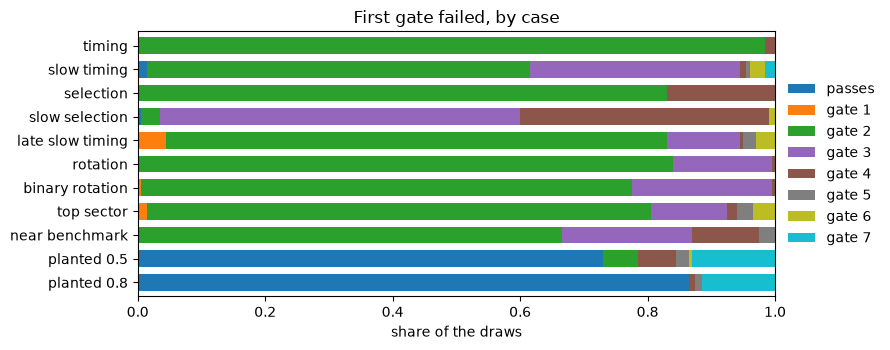

In [5]:
shares = stops.div(stops.sum(axis=1), axis=0)
ax = shares.plot.barh(stacked=True, figsize=(9, 3.6), colormap="tab10", width=0.7)
ax.invert_yaxis()
ax.set_xlabel("share of the draws")
ax.set_ylabel("")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
ax.set_title("First gate failed, by case")
plt.tight_layout()

## Each gate on its own

Every gate is computed on every case, so each gate's pass rate can be read alone. Gate 1 finds no
timing or data break in any case, as it should: every rule here reads the past only, and gate 1
judges a strategy's timing and data, not its edge; the tests plant the breaks it must catch. It
stops a few draws of the late nulls for fewer than 30 clustered decisions. Among gates 2 to 7, a
gate that no null ever failed would decide nothing.

In [6]:
gates = [f"gate {n}" for n in range(1, 8)]
alone = results.groupby("case")[gates].mean().reindex(ORDER)
alone.map(lambda v: f"{v:.0%}")

,gate 1,gate 2,gate 3,gate 4,gate 5,gate 6,gate 7
case,,,,,,,
timing,100%,2%,9%,0%,0%,4%,83%
slow timing,100%,40%,8%,13%,6%,26%,91%
selection,100%,17%,58%,0%,0%,46%,70%
slow selection,100%,97%,40%,2%,2%,36%,66%
late slow timing,96%,18%,6%,13%,4%,0%,94%
rotation,100%,16%,0%,0%,0%,0%,90%
binary rotation,100%,22%,0%,0%,0%,2%,86%
top sector,98%,20%,8%,8%,4%,11%,86%
near benchmark,100%,34%,13%,2%,0%,100%,88%


Gate 3 alone passes 8% and 7% of the timing nulls, fast and slow, and about as many of the late
ones: 6% of the late slow timing null, 8.5% of the top sector rule, and almost none of the two
rotations, always fully invested between funds that start early and funds that start late, whose
placebos are hard to beat; gate 5 cannot pass the rotations, which hold the benchmark until XLRE
starts, and their rows measure the gates before it. It passes 13.5% of the near-benchmark null,
whose placebos differ from it by little: gate 3's rank does not judge a rule this close to its
benchmark. Gates 2 and 4 together pass 2.5% of its draws, and gate 5 stops each of them: from 2012,
all three of its remaining blocks must be positive, and the blend of the variants must pass gates 2
to 4. A rule without skill that is not close to its benchmark beats 90% of its placebos about one
time in ten, and must pass the PSR as well. Gate 3 passes more than half of the fast selection nulls
and two in five of the slow ones, since the best of ten rules was chosen for its in-sample timing:
counting the tries is gate 4's work, and gate 4 stops them. The planted edges pass gate 3 on nearly
every draw.

## Neighbours that move nothing

Gate 6 moves each parameter of the base variant to its neighbours, and fails a card whose neighbours
set the base's targets on every session from its first holding: they test nothing. Where the targets
change only a few dozen times in-sample (a slow signal against the span moved, a pace of 21 sessions
or slower, a pick at an extreme rank), a span of 8 or 12 around 10 may move none of them: the
refusal stops about a sixth of the late slow timing null and of the top sector rule, both on a slow
signal, and 1 of the 200 draws of the near-benchmark null, on a fast one, whatever their edge. None
of those draws passed the other gates.

In [7]:
held = results.groupby("case")["neighbours holding the base"].apply(lambda n: (n > 0).mean()).reindex(ORDER)
held.map(lambda v: f"{v:.1%}").to_frame("draws with a neighbour that holds the base")

,draws with a neighbour that holds the base
case,
timing,0.0%
slow timing,0.0%
selection,0.0%
slow selection,0.0%
late slow timing,16.5%
rotation,0.0%
binary rotation,0.0%
top sector,18.5%
near benchmark,0.5%


## The selection null counts its trials

The selected rule is judged with the nine others in the registry. Gate 4 groups near-clones, trials
whose monthly hedged returns correlate at 0.9 or more, and counts each group once: rules driven by
independent signals should count as ten trials, and the best of them should not survive the
deflation of its edge. The registry holds eleven trials in every draw: the nine rules not chosen,
and the selected rule's two variants, which usually count once, as near-clones of each other, for
ten effective trials; when they correlate less, they count twice, for eleven.

In [8]:
selection = results[results["case"].isin(["selection", "slow selection"])]
counted = selection.groupby("case")["effective trials"].value_counts().unstack(fill_value=0)
counted.columns = [f"{int(c)} trials" for c in counted.columns]
print(counted.to_string())
print()
print(selection.groupby("case")["DSR"].describe(percentiles=[0.5, 0.95]).round(3).to_string())

                10 trials  11 trials
case                                
selection             199          1
slow selection        180         20

                count   mean    std    min    50%    95%    max
case                                                           
selection       200.0  0.112  0.095  0.006  0.083  0.292  0.662
slow selection  200.0  0.372  0.191  0.051  0.347  0.728  0.966


## The planted edges

The planted return's strength is set so that the rule's in-sample appraisal ratio averages the
target over 24 draws, every strength tried on the same draws; over the calibration's own 200 draws,
the averages come out a little above their targets. The rule's raw Sharpe ratio, shown beside it,
is higher at 0.5 and about the same at 0.8: the prices keep their drift, so the rule is also paid
for being invested, but its raw returns carry the market's swings too, which the appraisal ratio
leaves out. Each draw's appraisal
ratio scatters around its average nearly as much as sampling alone scatters a Sharpe ratio
estimated over eighteen years, whose standard error is about 0.24 (one over the square root of
eighteen): every draw shares one price history, and only the planted signal differs.

            strength      appraisal ratio        Sharpe       
                mean  std            mean    std   mean    std
case                                                          
planted 0.5    0.013  0.0           0.539  0.213  0.699  0.069
planted 0.8    0.018  0.0           0.844  0.210  0.797  0.069


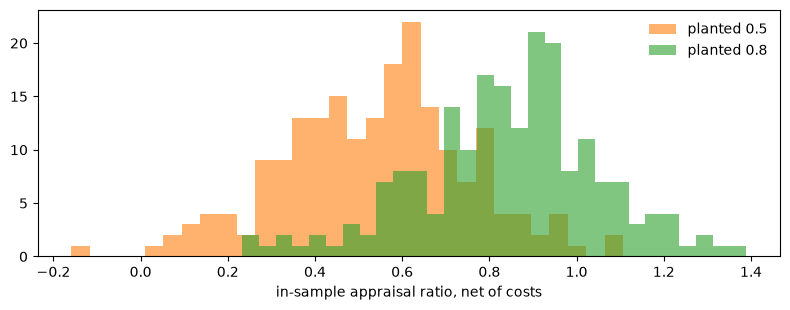

In [9]:
planted = results[results["case"].isin(PLANTED)]
print(planted.groupby("case")[["strength", "appraisal ratio", "Sharpe"]].agg(["mean", "std"]).round(3).to_string())
fig, ax = plt.subplots(figsize=(8, 3.2))
for case, colour in zip(PLANTED, ("tab:orange", "tab:green")):
    ax.hist(planted.loc[planted["case"] == case, "appraisal ratio"], bins=30, alpha=0.6, color=colour, label=case)
ax.set_xlabel("in-sample appraisal ratio, net of costs")
ax.legend(frameon=False)
plt.tight_layout()

## Power as the registry grows

Gate 4 deflates the edge by the number of trials the whole registry holds, so the same edge passes
less often as the lab tries more. Below, the share of planted edges that pass gates 1 to 7 as run,
with only their own two variants in the registry, and the share that would still pass against
registries of 10, 30 and 100 effective trials: gate 4, and the blend of gate 5, read the deflated
Sharpe ratio of the edge against the best of that many tries by luck. The trials' appraisal ratios
are taken to vary only as luck makes them vary; real trials differ more, and set a higher bar: these
are the best cases. An edge planted at 0.8 passes about half the time against 30 effective trials,
and about a third against 100: as the registry grows, only stronger edges get through.

In [10]:
registries = [c for c in results.columns if c.startswith("DSR against ")]
still = {c.removeprefix("DSR against ") + " trials": planted["passed"] & (planted[c] >= 0.9) for c in registries}
power = pd.DataFrame({"as run": planted["passed"], **still}).groupby(planted["case"]).mean().reindex(PLANTED)
power.map(lambda v: f"{v:.1%}")

,as run,10 trials,30 trials,100 trials
case,,,,
planted 0.5,73.0%,19.5%,10.5%,3.0%
planted 0.8,86.5%,71.0%,53.5%,35.0%


## What the calibration changed

The first version of the battery deflated the strategy's raw Sharpe ratio in gate 4, and grouped
near-clone trials on their raw returns. A long-only rule on these assets earns about the market's
Sharpe ratio with no edge at all, so that deflation tested the market; and since the raw returns
of long-only rules all correlate through the market, ten noise rules counted as fewer than ten
trials. The selection null passed more than the 5% allowed. Gate 4 now deflates the edge, whose
Sharpe ratio is the appraisal ratio, and judges near-clones on their monthly hedged returns.

Before any theory, the battery then changed again. Gate 1 checks every variant, on sessions where it
holds as well as where it sets a target: a rule that reads the future only to decide when to hold
broke nowhere else. Gate 3's placebos shift an asset's weight only where it trades both on the day
held and on the day the weight comes from, keep its own weight where that day comes before its
start, and fill the share of assets that do not trade yet with the strategy's own weights of the day
held. Shifted into cash before a late start, a rule without skill that held a late asset on the
rise, such as bitcoin, beat most of its placebos; left in place beside shifted weights, a late asset
changed the placebos' exposure, and a rule without skill that rotated between early and late funds
beat most of them; piled onto the assets that remain, a rule that held one or two assets beat 90% of
them on a fifth to a third of draws. The calibration gained the four nulls where assets start late,
and one close to its benchmark, where gate 3's rank judges little. Gate 6 fails a card whose
neighbours set the base's targets, which test nothing. Gate 5's best year is the year of the largest
edge, not of the largest return. Gate 7 checks every variant for timing inside the holdout, and for
in-sample positions rewritten once the holdout is seen. The calibration gained its slow nulls, and
its planted edges are set by appraisal ratio on prices that keep their drift: set by raw Sharpe
ratio on prices whose drift was removed, their appraisal ratios had been far above their names.